<h1> Pokemon </h1>

<h2> Análise Exploratória de Dados </h2>

In [1]:
# Importação de pacotes e bibliotecas
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score, classification_report

In [2]:
# Conectando ao googledrive
#from google.colab import drive
#drive.mount('/content/drive')

In [3]:
# Carregando a base de dados
#pokemons = pd.read_csv("/content/drive/MyDrive/artigos_site_rogersampaio/bases/Pokemon.csv")
pokemons = pd.read_csv("Pokemon.csv")
print(f"Base de dados carregada com sucesso. Dimensões {pokemons.shape[0]} linhas e {pokemons.shape[1]} colunas")
print(f"Nome de colunas {pokemons.columns}")

Base de dados carregada com sucesso. Dimensões 800 linhas e 13 colunas
Nome de colunas Index(['#', 'Name', 'Type 1', 'Type 2', 'Total', 'HP', 'Attack', 'Defense',
       'Sp. Atk', 'Sp. Def', 'Speed', 'Generation', 'Legendary'],
      dtype='object')


In [4]:
print(f"Qtde de tipos 1 pokemons únicos {pokemons['Type 1'].nunique()}")
print(f"tipos 1 únicos {pokemons['Type 1'].unique()}")

Qtde de tipos 1 pokemons únicos 18
tipos 1 únicos ['Grass' 'Fire' 'Water' 'Bug' 'Normal' 'Poison' 'Electric' 'Ground'
 'Fairy' 'Fighting' 'Psychic' 'Rock' 'Ghost' 'Ice' 'Dragon' 'Dark' 'Steel'
 'Flying']


In [5]:
# Verificando se há valores nulos
pokemons.isnull().sum()

#               0
Name            0
Type 1          0
Type 2        386
Total           0
HP              0
Attack          0
Defense         0
Sp. Atk         0
Sp. Def         0
Speed           0
Generation      0
Legendary       0
dtype: int64

In [6]:
# Tratando valores nulos em Type 2
pokemons['Type 2'].fillna('Desconhecido', inplace=True)
pokemons['Type 2'].isnull().sum()

0

In [7]:
# Distribuição de pokemons por tipo
pokemons.groupby('Type 1').size().sort_values(ascending=False)

Type 1
Water       112
Normal       98
Grass        70
Bug          69
Psychic      57
Fire         52
Electric     44
Rock         44
Ghost        32
Ground       32
Dragon       32
Dark         31
Poison       28
Fighting     27
Steel        27
Ice          24
Fairy        17
Flying        4
dtype: int64

<Axes: title={'center': 'Distribuição de pokemons por tipo'}, xlabel='Tipo 1', ylabel='Quantidade'>

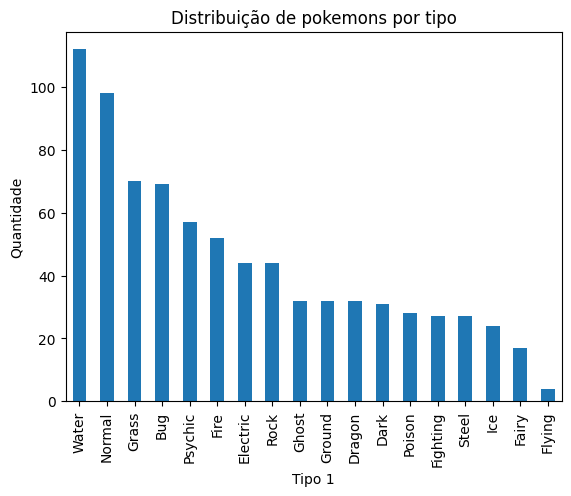

In [8]:
# Distribuição de pokemons por tipo
pokemons.groupby('Type 1').size().sort_values(ascending=False).plot(kind='bar',
                                                                    title = 'Distribuição de pokemons por tipo',
                                                                    ylabel='Quantidade',
                                                                    xlabel='Tipo 1')

In [9]:
# Explorando HP brevemente
pokemons['HP'].describe()

count    800.000000
mean      69.258750
std       25.534669
min        1.000000
25%       50.000000
50%       65.000000
75%       80.000000
max      255.000000
Name: HP, dtype: float64

Text(0.5, 1.0, 'Distribuição de HP')

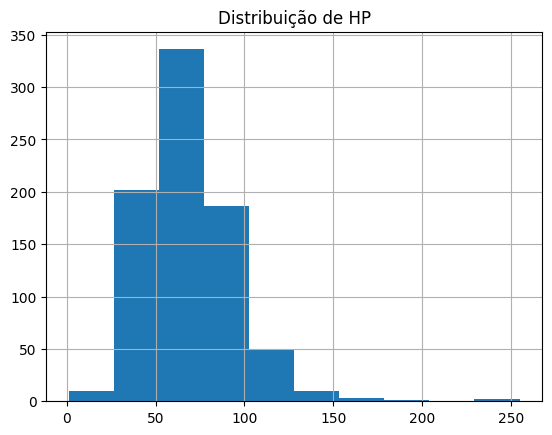

In [10]:
pokemons['HP'].hist().set_title('Distribuição de HP')

In [11]:
# Explorando Attack brevemente
pokemons['Attack'].describe()

count    800.000000
mean      79.001250
std       32.457366
min        5.000000
25%       55.000000
50%       75.000000
75%      100.000000
max      190.000000
Name: Attack, dtype: float64

Text(0.5, 1.0, 'Distribuição de Attack')

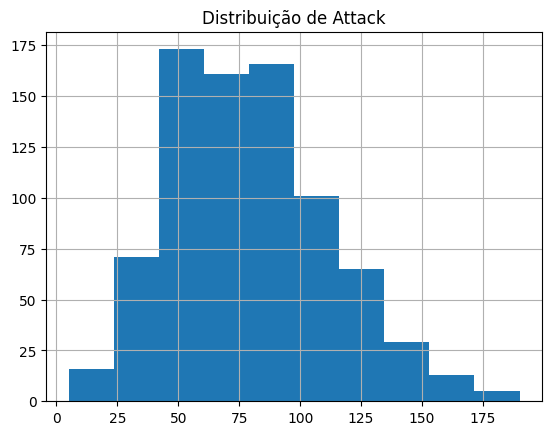

In [12]:
pokemons['Attack'].hist().set_title('Distribuição de Attack')

<h2> Construção do Modelo de Classificação </h2>

In [13]:
# 3. Selecionar features e label
X = pokemons[['Total', 'HP', 'Attack', 'Defense']]
y = pokemons['Type 1']

# 4. Dividir dados em treino e teste (70% treino / 30% teste)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# 5. Criar e treinar o modelo de Decision Tree
model = DecisionTreeClassifier(random_state=42)
model.fit(X_train, y_train)
print("Modelo treinado com sucesso!")

# 6. Fazer previsões
y_pred = model.predict(X_test)

Modelo treinado com sucesso!


In [14]:
# 7. Avaliar o desempenho
print("Acurácia:", accuracy_score(y_test, y_pred))
print("\nRelatório de Classificação Base de Teste :\n", classification_report(y_test, y_pred))

Acurácia: 0.15

Relatório de Classificação Base de Teste :
               precision    recall  f1-score   support

         Bug       0.33      0.33      0.33        21
        Dark       0.15      0.22      0.18         9
      Dragon       0.00      0.00      0.00        10
    Electric       0.15      0.15      0.15        13
       Fairy       0.00      0.00      0.00         5
    Fighting       0.00      0.00      0.00         8
        Fire       0.14      0.12      0.13        16
      Flying       0.00      0.00      0.00         1
       Ghost       0.29      0.20      0.24        10
       Grass       0.05      0.05      0.05        21
      Ground       0.08      0.10      0.09        10
         Ice       0.00      0.00      0.00         7
      Normal       0.16      0.17      0.17        29
      Poison       0.00      0.00      0.00         8
     Psychic       0.35      0.35      0.35        17
        Rock       0.21      0.31      0.25        13
       Steel       0.

In [15]:
# 1) Criar labels binárias: 1 = Fire, 0 = Not Fire
y_test_bin = (y_test == 'Fire').astype(int)
y_pred_bin = (y_pred == 'Fire').astype(int)

# 2) Matriz de confusão (ordem: [0,1] por padrão -> [Not Fire, Fire])
cm = confusion_matrix(y_test_bin, y_pred_bin)
tn, fp, fn, tp = cm.ravel()  # True Negative, False Positive, False Negative, True Positive

# 3) DataFrame legível com rótulos claros
cm_df = pd.DataFrame(
    [[tp, fp],
     [fn, tn]],
    index=['Actual Fire', 'Actual Not Fire'],
    columns=['Predicted Fire', 'Predicted Not Fire']
)

print("Matriz de confusão (binária) — Classe: Fire\n")
display(cm_df)

# 4) Métricas binárias
acc = accuracy_score(y_test_bin, y_pred_bin)
prec = precision_score(y_test_bin, y_pred_bin, zero_division=0)
rec = recall_score(y_test_bin, y_pred_bin, zero_division=0)
f1 = f1_score(y_test_bin, y_pred_bin, zero_division=0)

print(f"\nAcurácia: {acc:.4f}")
print(f"Precisão (Precision) para 'Fire': {prec:.4f}")
print(f"Recall (Sensibilidade) para 'Fire': {rec:.4f}")
print(f"F1-score para 'Fire': {f1:.4f}")

# 5) Relatório detalhado (opcional)
print("\nRelatório de classificação (binário — Fire vs Not Fire):\n")
print(classification_report(y_test_bin, y_pred_bin, target_names=['Not Fire','Fire'], zero_division=0))

Matriz de confusão (binária) — Classe: Fire



,Predicted Fire,Predicted Not Fire
Actual Fire,2,12
Actual Not Fire,14,212



Acurácia: 0.8917
Precisão (Precision) para 'Fire': 0.1429
Recall (Sensibilidade) para 'Fire': 0.1250
F1-score para 'Fire': 0.1333

Relatório de classificação (binário — Fire vs Not Fire):

              precision    recall  f1-score   support

    Not Fire       0.94      0.95      0.94       224
        Fire       0.14      0.12      0.13        16

    accuracy                           0.89       240
   macro avg       0.54      0.54      0.54       240
weighted avg       0.89      0.89      0.89       240



In [16]:
import pandas as pd

# Supondo que você já tenha:
# y_test_bin e y_pred_bin (Series binárias, 1 = Fire, 0 = Not Fire)

# 1️⃣ Concatenar lado a lado
comparacao = pd.concat(
    [pd.DataFrame(y_test_bin).reset_index(drop=True),
     pd.DataFrame(y_pred_bin).reset_index(drop=True)],
    axis=1
)

# 2️⃣ Renomear colunas
comparacao.columns = ['Real (Fire=1)', 'Previsto (Fire=1)']

# 3️⃣ Criar coluna indicando acerto ou erro
comparacao['Resultado'] = comparacao.apply(
    lambda x: '✅ Acertou' if x['Real (Fire=1)'] == x['Previsto (Fire=1)'] else '❌ Errou',
    axis=1
)

# 4️⃣ Visualizar primeiras linhas
print("Previsões do pokemons FIRE")
print(comparacao.head(15))

Previsões do pokemons FIRE
    Real (Fire=1)  Previsto (Fire=1)  Resultado
0               0                  0  ✅ Acertou
1               0                  0  ✅ Acertou
2               0                  0  ✅ Acertou
3               0                  0  ✅ Acertou
4               0                  0  ✅ Acertou
5               0                  0  ✅ Acertou
6               0                  0  ✅ Acertou
7               0                  0  ✅ Acertou
8               1                  0    ❌ Errou
9               0                  0  ✅ Acertou
10              0                  0  ✅ Acertou
11              1                  0    ❌ Errou
12              0                  0  ✅ Acertou
13              0                  0  ✅ Acertou
14              0                  0  ✅ Acertou


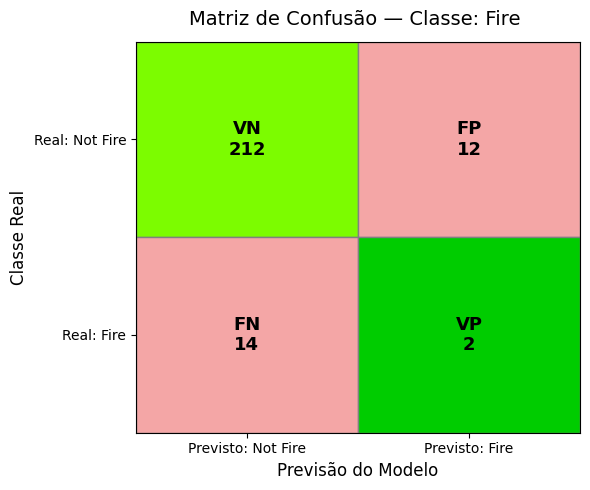

Acurácia: 0.8917
Precisão (Fire): 0.1429
Recall (Fire): 0.1250
F1-score (Fire): 0.1333


In [17]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score

# 1️⃣ Converter para binário: Fire = 1, Not Fire = 0
y_test_bin = (y_test == 'Fire').astype(int)
y_pred_bin = (y_pred == 'Fire').astype(int)

# 2️⃣ Matriz de confusão
cm = confusion_matrix(y_test_bin, y_pred_bin)
tn, fp, fn, tp = cm.ravel()

# 3️⃣ Criar labels com siglas + contagens
labels = [
    [f"VN\n{tn}", f"FP\n{fp}"],
    [f"FN\n{fn}", f"VP\n{tp}"]
]

# 4️⃣ Matriz de cores (verde para acertos, vermelho claro para erros)
colors = [
    ["#7CFC00", "#F4A6A6"],  # linha "Not Fire"
    ["#F4A6A6", "#00CC00"]   # linha "Fire"
]

# 5️⃣ Plot manual com Matplotlib
fig, ax = plt.subplots(figsize=(6, 5))

# desenhar cada célula manualmente
for i in range(2):
    for j in range(2):
        ax.add_patch(plt.Rectangle((j, i), 1, 1, color=colors[i][j], ec='gray'))

# adicionar textos centralizados
for i in range(2):
    for j in range(2):
        ax.text(j + 0.5, i + 0.5, labels[i][j],
                ha='center', va='center', fontsize=13, fontweight='bold')

# configurar eixos
ax.set_xticks([0.5, 1.5])
ax.set_yticks([0.5, 1.5])
ax.set_xticklabels(['Previsto: Not Fire', 'Previsto: Fire'])
ax.set_yticklabels(['Real: Not Fire', 'Real: Fire'])
ax.set_xlim(0, 2)
ax.set_ylim(0, 2)
ax.invert_yaxis()

plt.title("Matriz de Confusão — Classe: Fire ", fontsize=14, pad=12)
plt.xlabel("Previsão do Modelo", fontsize=12)
plt.ylabel("Classe Real", fontsize=12)
plt.tight_layout()
plt.show()

# 6️⃣ Métricas complementares
acc = accuracy_score(y_test_bin, y_pred_bin)
prec = precision_score(y_test_bin, y_pred_bin, zero_division=0)
rec = recall_score(y_test_bin, y_pred_bin, zero_division=0)
f1 = f1_score(y_test_bin, y_pred_bin, zero_division=0)

print(f"Acurácia: {acc:.4f}")
print(f"Precisão (Fire): {prec:.4f}")
print(f"Recall (Fire): {rec:.4f}")
print(f"F1-score (Fire): {f1:.4f}")